#  Kidney Disease Detection — Inception + MobileNetV2 Hybrid
### 4-Class Classification: Cyst | Normal | Stone | Tumor

**Model Architecture (from diagram):**
```
Input (224×224×3)
    ↓
MobileNetV2  (weights='imagenet' — pretrained, frozen initially)
    ↓
Inception Block  (+ L2 Regularisation + BatchNorm)
  ├─ Branch 1 : Conv2D(1×1) + BN + L2
  ├─ Branch 2 : Conv2D(1×1) → Conv2D(3×3) + BN + L2
  └─ Branch 3 : Conv2D(1×1) → Conv2D(5×5) + BN + L2
              Concatenate
    ↓
GlobalAveragePooling2D   (GAP)
    ↓
Dense(FC, ReLU, L2)      (FC layer — units tuned by Keras Tuner)
    ↓
Dropout                  (rate tuned by Keras Tuner)
    ↓
Dense(4, Softmax)        (Output)
```

**Key Changes from Original:**
1. `weights='imagenet'` — ImageNet pretraining
2. L2 regularisation + BatchNorm in Inception block
3. Keras Tuner (Bayesian Optimisation) for hyperparameter search

**Duplicate Strategy:**
- Phase 1 (before split): Remove cross-class duplicates via MD5 + pHash
- Phase 2 (after split) : Remove train images whose MD5/pHash matches val or test

---

##  Cell 1 — Install & Imports

In [ ]:
!pip install -q imagehash keras-tuner

import os, shutil, random, hashlib, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import imagehash
import keras_tuner as kt

warnings.filterwarnings('ignore')
SEED = 42
tf.random.set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f' TensorFlow  : {tf.__version__}')
print(f' Keras Tuner : {kt.__version__}')
print(f' GPU         : {tf.config.list_physical_devices("GPU")}')


 TensorFlow  : 2.19.0
 Keras Tuner : 1.4.8
 GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##  Cell 2 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  Cell 3 — Project Paths & Folder Setup

In [ ]:
BASE        = Path('/content/drive/MyDrive/Kidney____Project')
RAW_DIR     = BASE / 'data_raw'
CLEAN_DIR   = BASE / 'data_cleaned'
TRAIN_DIR   = CLEAN_DIR / 'train'
VAL_DIR     = CLEAN_DIR / 'val'
TEST_DIR    = CLEAN_DIR / 'test'
MODEL_DIR   = BASE / 'models'
OUTPUT_DIR  = BASE / 'outputs'

SOURCE_DATA = Path('/content/drive/MyDrive/data')  # ← your raw dataset
CLASSES     = ['cyst', 'normal', 'stone', 'tumor']
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32

for d in [RAW_DIR, CLEAN_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR, MODEL_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in CLASSES:
        (split_dir / cls).mkdir(parents=True, exist_ok=True)

print(' Project folders created')
for d in [RAW_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR, MODEL_DIR, OUTPUT_DIR]:
    print(f'   {d}')


 Project folders created
   /content/drive/MyDrive/Kidney____Project/data_raw
   /content/drive/MyDrive/Kidney____Project/data_cleaned/train
   /content/drive/MyDrive/Kidney____Project/data_cleaned/val
   /content/drive/MyDrive/Kidney____Project/data_cleaned/test
   /content/drive/MyDrive/Kidney____Project/models
   /content/drive/MyDrive/Kidney____Project/outputs


##  Cell 4 — Copy Raw Data → data_raw/

In [ ]:
print(' Copying MyDrive/data/ → data_raw/ …')
total = 0
for cls in CLASSES:
    src = SOURCE_DATA / cls
    dst = RAW_DIR / cls
    dst.mkdir(parents=True, exist_ok=True)
    n = 0
    if src.exists():
        for f in src.iterdir():
            if f.is_file():
                shutil.copy2(f, dst / f.name)
                n += 1
        total += n
        print(f'   {cls:8s}: {n} files')
    else:
        print(f'     Not found: {src}')
print(f'\n Total copied: {total} files')


 Copying MyDrive/data/ → data_raw/ …
   cyst    : 3709 files
   normal  : 5077 files
   stone   : 2954 files
   tumor   : 1398 files

 Total copied: 13138 files


##  Cell 5 — Hash Utilities

Centralised hash functions used across both deduplication phases.


In [ ]:
VALID_EXT = {'.jpg', '.jpeg', '.png'}

def is_valid_image(path):
    """Check extension AND fully decode the image (catches truncated files)."""
    if path.suffix.lower() not in VALID_EXT:
        return False
    try:
        with Image.open(path) as img:
            img.verify()                # header check
        # Re-open and FULLY LOAD pixel data (catches truncated files)
        with Image.open(path) as img:
            img.load()
        return True
    except Exception:
        return False

def get_md5(path):
    """MD5 hash of raw file bytes — catches exact duplicates."""
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            h.update(chunk)
    return h.hexdigest()

def get_phash(path):
    """Perceptual hash — catches visually similar / re-saved images."""
    try:
        return str(imagehash.phash(Image.open(path)))
    except Exception:
        return None

def build_hash_sets(directory):
    """
    Build (md5_set, phash_set) for all valid images in a directory tree.
    Used for post-split leakage detection.
    """
    md5_set   = set()
    phash_set = set()
    for cls in CLASSES:
        for f in (directory / cls).iterdir():
            if f.is_file() and is_valid_image(f):
                md5_set.add(get_md5(f))
                ph = get_phash(f)
                if ph:
                    phash_set.add(ph)
    return md5_set, phash_set

print(' Hash utilities defined')


 Hash utilities defined


##  Cell 6 — Phase 1 Cleaning: Corrupted Files + Cross-Class Duplicates

**Applied BEFORE splitting.**

| Rule | Action |
|------|--------|
| Corrupted / non-image file | ✗ Remove |
| Same-class duplicate (MD5 or pHash) | ✅ Keep |
| Cross-class duplicate (MD5 or pHash) | ✗ Remove |


In [ ]:
# ── Step A: Remove corrupted / non-image files ───────────────────
print(' Step A — Removing corrupted / non-image files …')
removed_bad = 0
for cls in CLASSES:
    for f in list((RAW_DIR / cls).iterdir()):
        if not f.is_file():
            continue
        if not is_valid_image(f):
            print(f'   ✗ {cls}/{f.name}')
            f.unlink()
            removed_bad += 1
print(f'   Removed {removed_bad} bad files\n')

# ── Step B: Build per-class hash maps ────────────────────────────
print(' Step B — Building hash maps for cross-class duplicate detection …')
md5_map   = defaultdict(list)   # md5   → [(cls, Path), ...]
phash_map = defaultdict(list)   # phash → [(cls, Path), ...]

for cls in CLASSES:
    for f in sorted((RAW_DIR / cls).iterdir()):
        if not f.is_file() or not is_valid_image(f):
            continue
        md5_map[get_md5(f)].append((cls, f))
        ph = get_phash(f)
        if ph:
            phash_map[ph].append((cls, f))

# ── Step C: Identify cross-class duplicates ───────────────────────
print(' Step C — Removing cross-class duplicates …')
to_remove = set()

for h_map in (md5_map, phash_map):
    for h, entries in h_map.items():
        unique_classes = {c for c, _ in entries}
        if len(unique_classes) > 1:          # found in multiple classes
            seen_cls = set()
            for c, p in entries:
                if c in seen_cls:
                    to_remove.add(p)         # keep one per class, remove extras
                else:
                    seen_cls.add(c)

print(f'   Cross-class duplicates to remove: {len(to_remove)}')
for p in to_remove:
    print(f'   ✗ Removed: {p.parent.name}/{p.name}')
    p.unlink()
print('    Cross-class duplicate removal complete\n')

# ── Step D: Copy cleaned images → data_cleaned/<class>/ ──────────
print(' Step D — Copying to data_cleaned/ …')
for cls in CLASSES:
    dst = CLEAN_DIR / cls
    dst.mkdir(parents=True, exist_ok=True)
    n = 0
    for f in (RAW_DIR / cls).iterdir():
        if f.is_file() and is_valid_image(f):
            shutil.copy2(f, dst / f.name)
            n += 1
    print(f'   {cls:8s}: {n} images')
print('\n Phase 1 cleaning complete')


 Step A — Removing corrupted / non-image files …
   Removed 0 bad files

 Step B — Building hash maps for cross-class duplicate detection …
 Step C — Removing cross-class duplicates …
   Cross-class duplicates to remove: 0
    Cross-class duplicate removal complete

 Step D — Copying to data_cleaned/ …
   cyst    : 3709 images
   normal  : 5077 images
   stone   : 2954 images
   tumor   : 1398 images

 Phase 1 cleaning complete


##  Cell 7 — Data Splitting (70 / 15 / 15)

In [ ]:
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

print(' Splitting: 70% train | 15% val | 15% test …')
for cls in CLASSES:
    files = sorted((CLEAN_DIR / cls).glob('*'))
    files = [f for f in files if f.is_file() and is_valid_image(f)]
    random.shuffle(files)

    n     = len(files)
    n_tr  = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)

    train_f = files[:n_tr]
    val_f   = files[n_tr : n_tr + n_val]
    test_f  = files[n_tr + n_val :]

    for f in train_f: shutil.copy2(f, TRAIN_DIR / cls / f.name)
    for f in val_f:   shutil.copy2(f, VAL_DIR   / cls / f.name)
    for f in test_f:  shutil.copy2(f, TEST_DIR  / cls / f.name)

    print(f'   {cls:8s}: train={len(train_f):4d} | val={len(val_f):4d} | test={len(test_f):4d}')

print('\n Initial split complete')


 Splitting: 70% train | 15% val | 15% test …
   cyst    : train=2596 | val= 556 | test= 557
   normal  : train=3553 | val= 761 | test= 763
   stone   : train=2067 | val= 443 | test= 444
   tumor   : train= 978 | val= 209 | test= 211

 Initial split complete


##  Cell 8 — Phase 2: Post-Split Hash-Based Leakage Prevention

**Applied AFTER splitting.** This is the key upgrade over simple filename-based guards.

```
Algorithm:
  1. Build MD5 set + pHash set for VALIDATION folder
  2. Build MD5 set + pHash set for TEST folder
  3. For each image in TRAIN:
       if md5(img) ∈ val_md5_set   → REMOVE from train
       if phash(img) ∈ val_ph_set  → REMOVE from train
       if md5(img) ∈ test_md5_set  → REMOVE from train  (recommended)
       if phash(img) ∈ test_ph_set → REMOVE from train  (recommended)
  4. Val and Test remain UNCHANGED
```


In [ ]:
print(' Phase 2 — Post-split hash-based leakage prevention …\n')

# ── Build reference hash sets from val and test ───────────────────
print('   Computing hashes for validation set …')
val_md5_set, val_ph_set = build_hash_sets(VAL_DIR)
print(f'   Val  : {len(val_md5_set)} MD5 | {len(val_ph_set)} pHash')

print('   Computing hashes for test set …')
test_md5_set, test_ph_set = build_hash_sets(TEST_DIR)
print(f'   Test : {len(test_md5_set)} MD5 | {len(test_ph_set)} pHash\n')

# ── Combine reference sets ────────────────────────────────────────
ref_md5_set = val_md5_set | test_md5_set
ref_ph_set  = val_ph_set  | test_ph_set

# ── Scan training set and remove leaked images ────────────────────
print('   Scanning training set for leakage …')
total_removed = 0

for cls in CLASSES:
    removed_cls = 0
    for f in list((TRAIN_DIR / cls).iterdir()):
        if not f.is_file() or not is_valid_image(f):
            continue
        md5 = get_md5(f)
        ph  = get_phash(f)

        leaked = (md5 in ref_md5_set) or (ph is not None and ph in ref_ph_set)

        if leaked:
            print(f'   ✗ Leakage removed: {cls}/{f.name}')
            f.unlink()
            removed_cls += 1

    total_removed += removed_cls
    print(f'   {cls:8s}: {removed_cls} leaked images removed from train')

print(f'\n   Total leakage removals : {total_removed}')
print('   Val / Test sets        : UNCHANGED')
print('\n Phase 2 complete — zero data leakage guaranteed')


 Phase 2 — Post-split hash-based leakage prevention …

   Computing hashes for validation set …
   Val  : 1951 MD5 | 1685 pHash
   Computing hashes for test set …
   Test : 1963 MD5 | 1714 pHash

   Scanning training set for leakage …
   ✗ Leakage removed: cyst/Cyst- (351).jpg
   ✗ Leakage removed: cyst/Cyst- (1692).jpg
   ✗ Leakage removed: cyst/Cyst- (3201).jpg
   ✗ Leakage removed: cyst/Cyst- (292).jpg
   ✗ Leakage removed: cyst/Cyst- (3690).jpg
   ✗ Leakage removed: cyst/Cyst- (744).jpg
   ✗ Leakage removed: cyst/Cyst- (2769).jpg
   ✗ Leakage removed: cyst/Cyst- (96).jpg
   ✗ Leakage removed: cyst/Cyst- (3083).jpg
   ✗ Leakage removed: cyst/Cyst- (3549).jpg
   ✗ Leakage removed: cyst/Cyst- (2892).jpg
   ✗ Leakage removed: cyst/Cyst- (1155).jpg
   ✗ Leakage removed: cyst/Cyst- (1184).jpg
   ✗ Leakage removed: cyst/Cyst- (294).jpg
   ✗ Leakage removed: cyst/Cyst- (2893).jpg
   ✗ Leakage removed: cyst/Cyst- (2346).jpg
   ✗ Leakage removed: cyst/Cyst- (1691).jpg
   ✗ Leakage removed: c

##  Cell 9 — Exploratory Data Analysis (EDA)

Class        Train     Val    Test   Total
──────────────────────────────────────────
cyst          1329     556     557    2442
normal        2043     761     763    3567
stone         1512     443     444    2399
tumor          577     209     211     997


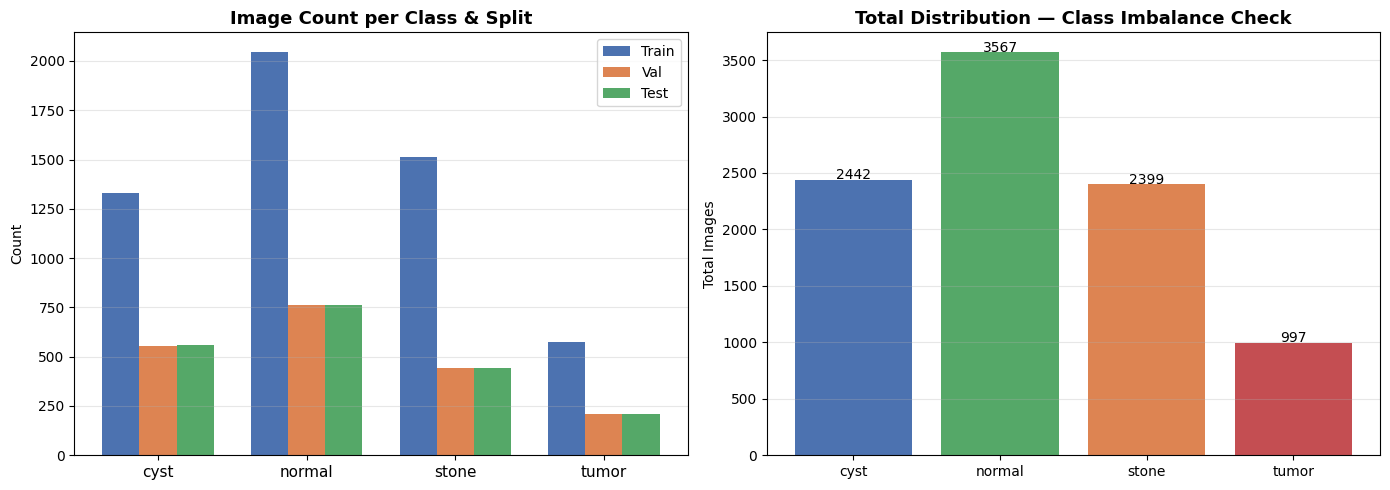

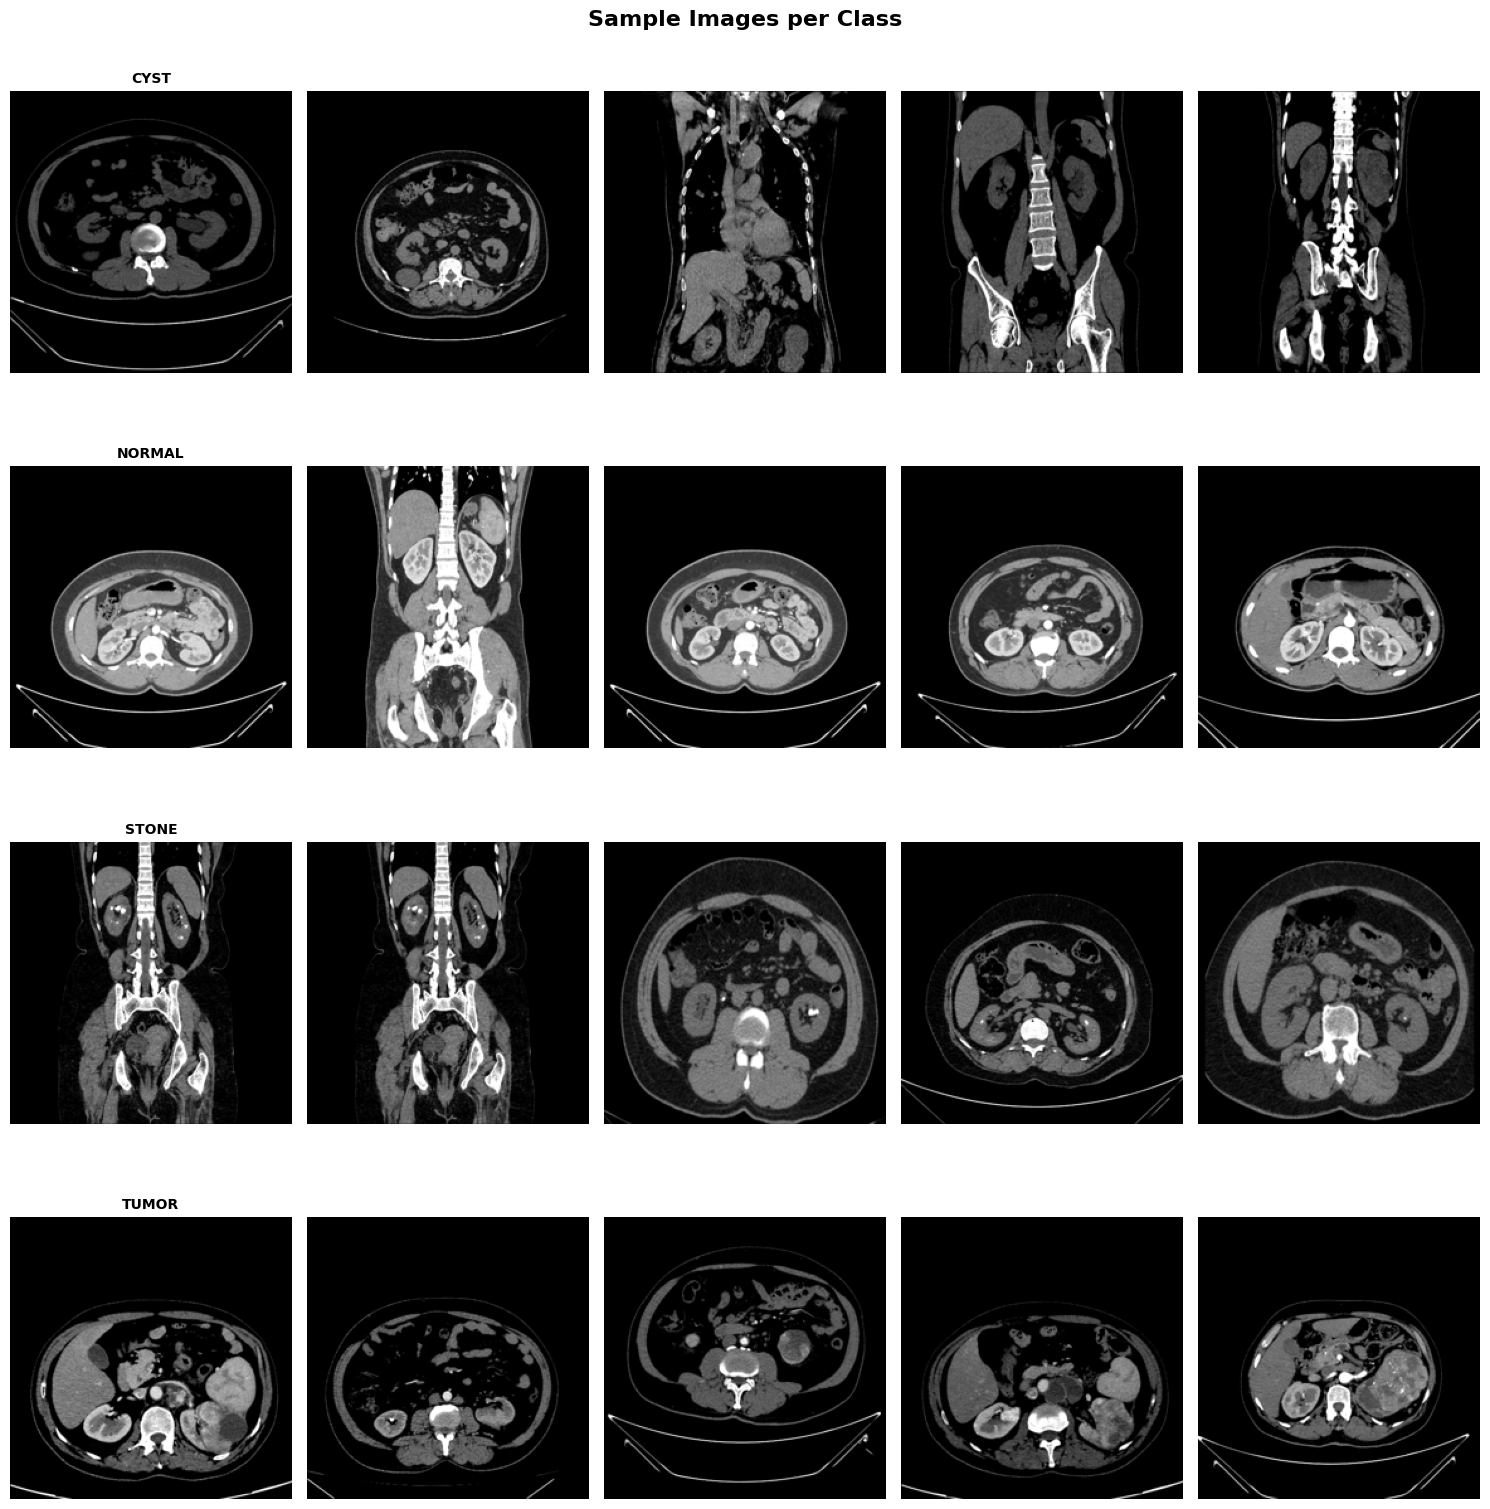

 EDA plots saved → /content/drive/MyDrive/Kidney____Project/outputs


In [ ]:
# ── Count images ──────────────────────────────────────────────────
dirs   = {'train': TRAIN_DIR, 'val': VAL_DIR, 'test': TEST_DIR}
counts = {s: {c: len(list((d/c).glob('*'))) for c in CLASSES} for s,d in dirs.items()}
counts['total'] = {c: sum(counts[s][c] for s in dirs) for c in CLASSES}

print(f"{'Class':10s} {'Train':>7} {'Val':>7} {'Test':>7} {'Total':>7}")
print('─' * 42)
for cls in CLASSES:
    print(f"{cls:10s} {counts['train'][cls]:>7} {counts['val'][cls]:>7} "
          f"{counts['test'][cls]:>7} {counts['total'][cls]:>7}")

# ── Bar charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(CLASSES)); w = 0.25
pal = ['#4C72B0', '#DD8452', '#55A868']
for i, (split, color) in enumerate(zip(['train','val','test'], pal)):
    axes[0].bar(x+i*w, [counts[split][c] for c in CLASSES],
                w, label=split.capitalize(), color=color)
axes[0].set_xticks(x+w); axes[0].set_xticklabels(CLASSES, fontsize=11)
axes[0].set_title('Image Count per Class & Split', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

totals = [counts['total'][c] for c in CLASSES]
bars   = axes[1].bar(CLASSES, totals, color=['#4C72B0','#55A868','#DD8452','#C44E52'])
axes[1].set_title('Total Distribution — Class Imbalance Check',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Images'); axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, totals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Sample image grid ─────────────────────────────────────────────
fig, axes = plt.subplots(len(CLASSES), 5, figsize=(15, 4*len(CLASSES)))
fig.suptitle('Sample Images per Class', fontsize=16, fontweight='bold')
for r, cls in enumerate(CLASSES):
    imgs = list((TRAIN_DIR/cls).glob('*'))[:5]
    for c in range(5):
        ax = axes[r][c]
        if c < len(imgs):
            ax.imshow(Image.open(imgs[c]).resize((224,224)))
            if c == 0: ax.set_title(cls.upper(), fontweight='bold', fontsize=10)
        ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print(f' EDA plots saved → {OUTPUT_DIR}')


##  Cell 10 — Data Generators & Augmentation

Augmentation applied **only on training data**. Val/Test use rescaling only.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)
base_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='sparse', shuffle=True, seed=SEED
)
val_gen = base_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='sparse', shuffle=False
)
test_gen = base_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='sparse', shuffle=False
)

print('Class indices :', train_gen.class_indices)
print(f'Train batches : {len(train_gen)}')
print(f'Val   batches : {len(val_gen)}')
print(f'Test  batches : {len(test_gen)}')


Found 5461 images belonging to 4 classes.
Found 1969 images belonging to 4 classes.
Found 1975 images belonging to 4 classes.
Class indices : {'cyst': 0, 'normal': 1, 'stone': 2, 'tumor': 3}
Train batches : 171
Val   batches : 62
Test  batches : 62


##  Cell 11 — Model Architecture

**Changes from original:**
- `weights='imagenet'` → Pretrained on ImageNet (no ImageNet pretraining)
- `base.trainable = False` → start with backbone frozen (required for weights=None)
- L2 regularisation on all Conv2D layers in the Inception block
- BatchNorm after every Conv2D in the Inception block
- L2 regularisation on the Dense (FC) layer

```
Input (224×224×3)
      │
      ▼
 MobileNetV2  ← weights='imagenet' (pretrained), FROZEN initially
      │
      ▼
 ┌────────────────────────────────────────────────────────────┐
 │         INCEPTION BLOCK  (+ L2 + BatchNorm)               │
 │  ┌────────────────┐ ┌──────────────────┐ ┌────────────────────┐ │
 │  │1×1 Conv+BN+L2  │ │1×1→3×3 +BN+L2   │ │1×1→5×5 +BN+L2     │ │
 │  └────────────────┘ └──────────────────┘ └────────────────────┘ │
 │               Concatenate + BatchNorm                     │
 └────────────────────────────────────────────────────────────┘
      │
      ▼
 GlobalAveragePooling2D   (H×W×C → C)
      │
      ▼
 Dense(FC, ReLU, L2)      FC Layer
      │
      ▼
 Dropout
      │
      ▼
 Dense(4, Softmax)        Output
```


In [ ]:
# ── Default regularisation strength (tuned later by Keras Tuner) ──
L2_LAMBDA = 1e-4

def inception_block(x, f_1x1, f_3x3r, f_3x3, f_5x5r, f_5x5,
                    l2_lambda=L2_LAMBDA):
    """
    Lightweight custom Inception-style block with regularisation.

    Three parallel branches:
      Branch 1 : 1×1 Conv           (channel-wise compression)
      Branch 2 : 1×1 reduce → 3×3   (local spatial features)
      Branch 3 : 1×1 reduce → 5×5   (wider context features)

    Regularisation applied to every Conv2D:
      • L2 weight regularisation       (penalises large weights)
      • BatchNormalisation after Conv2D (stabilises activations)
    """
    reg = regularizers.l2(l2_lambda)

    # Branch 1 ── 1×1 convolution
    b1 = layers.Conv2D(f_1x1, kernel_size=1, padding='same',
                       kernel_regularizer=reg,
                       name='incept_b1_1x1')(x)
    b1 = layers.BatchNormalization(name='incept_b1_bn')(b1)
    b1 = layers.Activation('relu', name='incept_b1_relu')(b1)

    # Branch 2 ── 1×1 bottleneck → 3×3
    b2 = layers.Conv2D(f_3x3r, kernel_size=1, padding='same',
                       kernel_regularizer=reg,
                       name='incept_b2_reduce')(x)
    b2 = layers.BatchNormalization(name='incept_b2_reduce_bn')(b2)
    b2 = layers.Activation('relu', name='incept_b2_reduce_relu')(b2)
    b2 = layers.Conv2D(f_3x3, kernel_size=3, padding='same',
                       kernel_regularizer=reg,
                       name='incept_b2_3x3')(b2)
    b2 = layers.BatchNormalization(name='incept_b2_3x3_bn')(b2)
    b2 = layers.Activation('relu', name='incept_b2_3x3_relu')(b2)

    # Branch 3 ── 1×1 bottleneck → 5×5
    b3 = layers.Conv2D(f_5x5r, kernel_size=1, padding='same',
                       kernel_regularizer=reg,
                       name='incept_b3_reduce')(x)
    b3 = layers.BatchNormalization(name='incept_b3_reduce_bn')(b3)
    b3 = layers.Activation('relu', name='incept_b3_reduce_relu')(b3)
    b3 = layers.Conv2D(f_5x5, kernel_size=5, padding='same',
                       kernel_regularizer=reg,
                       name='incept_b3_5x5')(b3)
    b3 = layers.BatchNormalization(name='incept_b3_5x5_bn')(b3)
    b3 = layers.Activation('relu', name='incept_b3_5x5_relu')(b3)

    # Concatenate all branches
    out = layers.Concatenate(name='incept_concat')([b1, b2, b3])
    return out


def build_model(num_classes=4, input_shape=(224, 224, 3),
                learning_rate=1e-3, fc_units=128,
                dropout_rate=0.5, l2_lambda=L2_LAMBDA):
    """
    KidneyNet: MobileNetV2 (weights='imagenet') + Regularised Inception Block
              + GAP + FC + Dropout + Softmax(4)

    Parameters configurable by Keras Tuner:
      - learning_rate : Adam optimizer LR
      - fc_units      : Dense layer neurons
      - dropout_rate  : Dropout probability
      - l2_lambda     : L2 regularisation strength
    """
    reg = regularizers.l2(l2_lambda)

    # 1. MobileNetV2 backbone — weights='imagenet' (PRETRAINED)
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = False   # ← Freeze base initially for Transfer Learning

    # 2. Input → backbone
    inputs = keras.Input(shape=input_shape, name='input_images')
    x = base(inputs, training=False)   # ← BN in inference mode (CRITICAL for Transfer Learning)

    # 3. Custom Inception block with L2 + BatchNorm regularisation
    x = inception_block(x, f_1x1=32, f_3x3r=16, f_3x3=32,
                        f_5x5r=8, f_5x5=16, l2_lambda=l2_lambda)
    x = layers.BatchNormalization(name='incept_bn')(x)

    # 4. GlobalAveragePooling2D  (NOT Flatten)
    #    Converts (H, W, C) feature maps → flat (C,) vector
    #    Reduces params significantly and prevents overfitting
    x = layers.GlobalAveragePooling2D(name='GAP')(x)

    # 5. Fully Connected layer with L2 regularisation
    x = layers.Dense(fc_units, activation='relu',
                     kernel_regularizer=reg, name='FC')(x)

    # 6. Dropout — prevents co-adaptation of neurons
    x = layers.Dropout(dropout_rate, name='Dropout')(x)

    # 7. Output with Softmax
    outputs = layers.Dense(num_classes, activation='softmax',
                           name='Softmax_output')(x)

    model = Model(inputs, outputs, name='KidneyNet')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_model()
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "KidneyNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_images        │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_images[0][… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b2_reduce    │ (None, 7, 7, 16)  │     20,496 │ mobilenetv2_1.00… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b3_reduce    │ (None, 7, 7, 8)   │     10,248 │ mobilenetv2_1.00… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b2_reduce_bn │ (None, 7, 7, 16)  │         64 │ incept_b2_reduce… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b3_reduce_bn │ (None, 7, 7, 8)   │         32 │ incept_b3_reduce… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b2_reduce_r… │ (None, 7, 7, 16)  │          0 │ incept_b2_reduce… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b3_reduce_r… │ (None, 7, 7, 8)   │          0 │ incept_b3_reduce… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b1_1x1       │ (None, 7, 7, 32)  │     40,992 │ mobilenetv2_1.00… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b2_3x3       │ (None, 7, 7, 32)  │      4,640 │ incept_b2_reduce… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b3_5x5       │ (None, 7, 7, 16)  │      3,216 │ incept_b3_reduce… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b1_bn        │ (None, 7, 7, 32)  │        128 │ incept_b1_1x1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b2_3x3_bn    │ (None, 7, 7, 32)  │        128 │ incept_b2_3x3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b3_5x5_bn    │ (None, 7, 7, 16)  │         64 │ incept_b3_5x5[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b1_relu      │ (None, 7, 7, 32)  │          0 │ incept_b1_bn[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b2_3x3_relu  │ (None, 7, 7, 32)  │          0 │ incept_b2_3x3_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b3_5x5_relu  │ (None, 7, 7, 16)  │          0 │ incept_b3_5x5_bn

 Total params: 2,349,196 (8.96 MB)

 Trainable params: 90,844 (354.86 KB)

 Non-trainable params: 2,258,352 (8.61 MB)

##  Cell 11b — Keras Tuner: Hyperparameter Optimisation

Uses **Bayesian Optimisation** to search the best combination of:
| Hyperparameter | Search Space |
|----------------|-------------|
| Learning Rate  | 1e-2, 1e-3, 1e-4 |
| FC Units       | 64, 128, 256 |
| Dropout Rate   | 0.3, 0.4, 0.5, 0.6 |
| L2 Lambda      | 1e-3, 1e-4, 1e-5 |

The best model from the search is used for full training in the next cells.


In [ ]:
def build_model_for_tuner(hp):
    """
    Wrapper around build_model() that exposes hyperparameters
    to the Keras Tuner search space.
    """
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    fc_units      = hp.Choice('fc_units',      values=[64, 128, 256])
    dropout_rate  = hp.Choice('dropout_rate',   values=[0.3, 0.4, 0.5, 0.6])
    l2_lambda     = hp.Choice('l2_lambda',      values=[1e-3, 1e-4, 1e-5])

    return build_model(
        learning_rate=learning_rate,
        fc_units=fc_units,
        dropout_rate=dropout_rate,
        l2_lambda=l2_lambda
    )


# ── Configure the tuner ──────────────────────────────────────────
TUNER_DIR = str(BASE / 'keras_tuner')

tuner = kt.BayesianOptimization(
    hypermodel=build_model_for_tuner,
    objective='val_accuracy',
    max_trials=5,           # number of HP combos to try
    executions_per_trial=1,  # 1 execution per trial (faster)
    directory=TUNER_DIR,
    project_name='kidney_tuner',
    overwrite=True,
    seed=SEED
)

tuner.search_space_summary()

# ── Run the HP search  (short epochs to be fast) ─────────────────
print('\n Starting Keras Tuner search …')
tuner.search(
    train_gen,
    validation_data=val_gen,
    epochs=10,               # short search epochs
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3,
                      restore_best_weights=True)
    ],
    verbose=1
)

# ── Extract best hyperparameters ─────────────────────────────────
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print('\n' + '='*55)
print('    Best Hyperparameters Found')
print('='*55)
print(f'  Learning Rate : {best_hp.get("learning_rate")}')
print(f'  FC Units      : {best_hp.get("fc_units")}')
print(f'  Dropout Rate  : {best_hp.get("dropout_rate")}')
print(f'  L2 Lambda     : {best_hp.get("l2_lambda")}')
print('='*55)

# ── Rebuild the model with best HPs for full training ────────────
model = build_model(
    learning_rate=best_hp.get('learning_rate'),
    fc_units=best_hp.get('fc_units'),
    dropout_rate=best_hp.get('dropout_rate'),
    l2_lambda=best_hp.get('l2_lambda')
)
model.summary()
print('\n Model rebuilt with best Keras Tuner hyperparameters')


Trial 5 Complete [00h 17m 10s]
val_accuracy: 0.9344844818115234

Best val_accuracy So Far: 0.9344844818115234
Total elapsed time: 01h 30m 00s

    Best Hyperparameters Found
  Learning Rate : 0.001
  FC Units      : 64
  Dropout Rate  : 0.4
  L2 Lambda     : 0.0001


Model: "KidneyNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_images        │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_images[0][… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b2_reduce    │ (None, 7, 7, 16)  │     20,496 │ mobilenetv2_1.00… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b3_reduce    │ (None, 7, 7, 8)   │     10,248 │ mobilenetv2_1.00… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b2_reduce_bn │ (None, 7, 7, 16)  │         64 │ incept_b2_reduce… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b3_reduce_bn │ (None, 7, 7, 8)   │         32 │ incept_b3_reduce… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b2_reduce_r… │ (None, 7, 7, 16)  │          0 │ incept_b2_reduce… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b3_reduce_r… │ (None, 7, 7, 8)   │          0 │ incept_b3_reduce… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b1_1x1       │ (None, 7, 7, 32)  │     40,992 │ mobilenetv2_1.00… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b2_3x3       │ (None, 7, 7, 32)  │      4,640 │ incept_b2_reduce… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b3_5x5       │ (None, 7, 7, 16)  │      3,216 │ incept_b3_reduce… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b1_bn        │ (None, 7, 7, 32)  │        128 │ incept_b1_1x1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b2_3x3_bn    │ (None, 7, 7, 32)  │        128 │ incept_b2_3x3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b3_5x5_bn    │ (None, 7, 7, 16)  │         64 │ incept_b3_5x5[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b1_relu      │ (None, 7, 7, 32)  │          0 │ incept_b1_bn[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b2_3x3_relu  │ (None, 7, 7, 32)  │          0 │ incept_b2_3x3_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ incept_b3_5x5_relu  │ (None, 7, 7, 16)  │          0 │ incept_b3_5x5_bn

 Total params: 2,343,756 (8.94 MB)

 Trainable params: 85,404 (333.61 KB)

 Non-trainable params: 2,258,352 (8.61 MB)


 Model rebuilt with best Keras Tuner hyperparameters


##  Cell 12 — Phase 1 Training (Head Only — Frozen Base)

Only the Inception block and FC head are trained. The MobileNetV2 backbone remains FROZEN to preserve ImageNet features.
- **Optimizer:** Adam (LR from Keras Tuner best HP)
- **EarlyStopping:** patience = 3, monitor = val_loss


In [ ]:
callbacks_p1 = [
    EarlyStopping(
        monitor='val_loss', patience=10,  # Updated: patience=10
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, verbose=1
    )
]

best_lr = best_hp.get('learning_rate')
print(f' Phase 1 — Frozen base (Head only), LR={best_lr}, max 30 epochs …')
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_p1,
    verbose=1
)


 Phase 1 — Frozen base (Head only), LR=0.001, max 30 epochs …
Epoch 1/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 153s 796ms/step - accuracy: 0.7654 - loss: 0.6583 - val_accuracy: 0.8334 - val_loss: 0.4820 - learning_rate: 0.0010
Epoch 2/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 122s 715ms/step - accuracy: 0.8958 - loss: 0.3234 - val_accuracy: 0.8329 - val_loss: 0.4576 - learning_rate: 0.0010
Epoch 3/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 128s 747ms/step - accuracy: 0.9225 - loss: 0.2525 - val_accuracy: 0.8197 - val_loss: 0.5485 - learning_rate: 0.0010
Epoch 4/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 126s 733ms/step - accuracy: 0.9354 - loss: 0.2108 - val_accuracy: 0.9137 - val_loss: 0.2813 - learning_rate: 0.0010
Epoch 5/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 126s 737ms/step - accuracy: 0.9449 - loss: 0.1865 - val_accuracy: 0.8827 - val_loss: 0.4449 - learning_rate: 0.0010
Epoch 6/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.9494 - loss: 0.1677
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.000500000023748

##  Cell 13 — Phase 1 Training Curves

   Saved → /content/drive/MyDrive/Kidney____Project/outputs/training_phase1.png


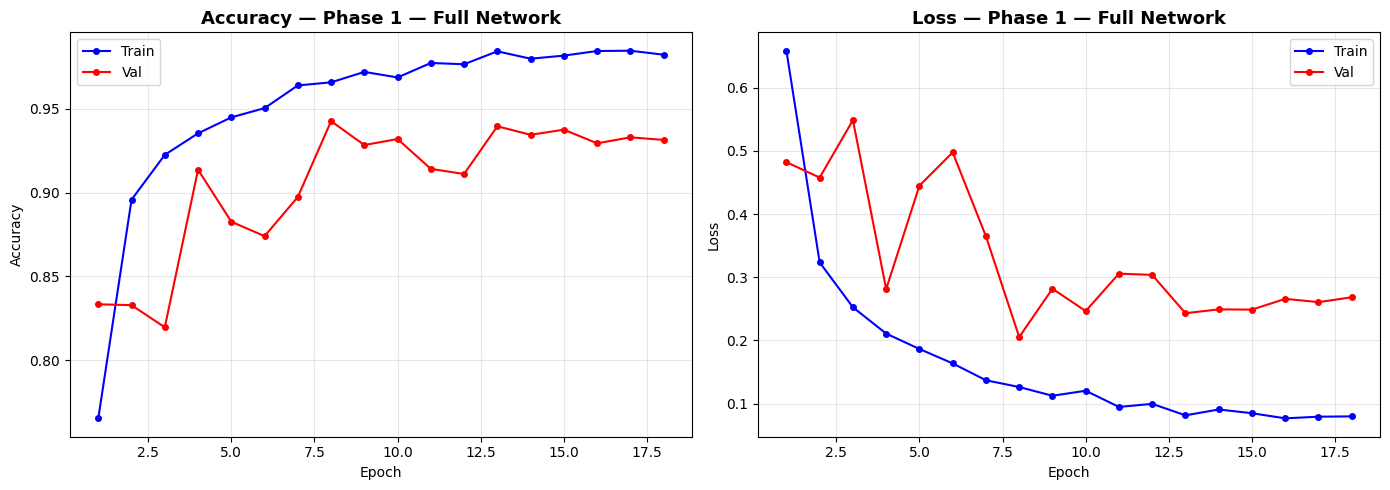

In [ ]:
def plot_history(history, label, save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(history.history['accuracy']) + 1)

    ax1.plot(ep, history.history['accuracy'],     'b-o', ms=4, label='Train')
    ax1.plot(ep, history.history['val_accuracy'], 'r-o', ms=4, label='Val')
    ax1.set_title(f'Accuracy — {label}', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(ep, history.history['loss'],     'b-o', ms=4, label='Train')
    ax2.plot(ep, history.history['val_loss'], 'r-o', ms=4, label='Val')
    ax2.set_title(f'Loss — {label}', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'   Saved → {save_path}')
    plt.show()

plot_history(history1, 'Phase 1 — Full Network',
             save_path=OUTPUT_DIR/'training_phase1.png')


##  Cell 14 — Phase 2: Fine-Tuning with Lower LR

Continue training with a **reduced learning rate** (best_lr / 10) for refinement.


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# ── Phase 2: Unfreeze & Fine-Tune ──────────────────────────────────
print(' Unfreezing top 30 MobileNetV2 layers for fine-tuning ...')

base_model = model.layers[1]  # MobileNetV2 index
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f'   Trainable base layers : {sum(1 for l in base_model.layers if l.trainable)}')

# Use a very low LR for fine-tuning to avoid destroying weights
finetune_lr = 1e-5
print(f' Phase 2 — Fine-tuning with LR={finetune_lr} ...')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=finetune_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    EarlyStopping(
        monitor='val_loss', patience=10,  # Updated: patience=10
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1
    ),
    ModelCheckpoint(str(MODEL_DIR / 'best_final_model.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks_p2,
    verbose=1
)

print('\n Transfer Learning Pipeline Complete!')

 Unfreezing top 30 MobileNetV2 layers for fine-tuning ...
   Trainable base layers : 30
 Phase 2 — Fine-tuning with LR=1e-05 ...
Epoch 1/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.8104 - loss: 0.6342
Epoch 1: val_accuracy improved from None to 0.94058, saving model to /content/drive/MyDrive/Kidney____Project/models/best_final_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Kidney____Project/models/best_final_model.keras
171/171 ━━━━━━━━━━━━━━━━━━━━ 169s 843ms/step - accuracy: 0.8407 - loss: 0.5192 - val_accuracy: 0.9406 - val_loss: 0.2687 - learning_rate: 1.0000e-05
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.8875 - loss: 0.3678
Epoch 2: val_accuracy improved from 0.94058 to 0.94363, saving model to /content/drive/MyDrive/Kidney____Project/models/best_final_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Kidney____Project/models/best_final_model.keras
171/171 ━━━━━━━━━━━━━━━━━━━━ 121s 710ms/step - accu

##  Cell 15 — Phase 2 Training Curves

   Saved → /content/drive/MyDrive/Kidney____Project/outputs/training_phase2.png


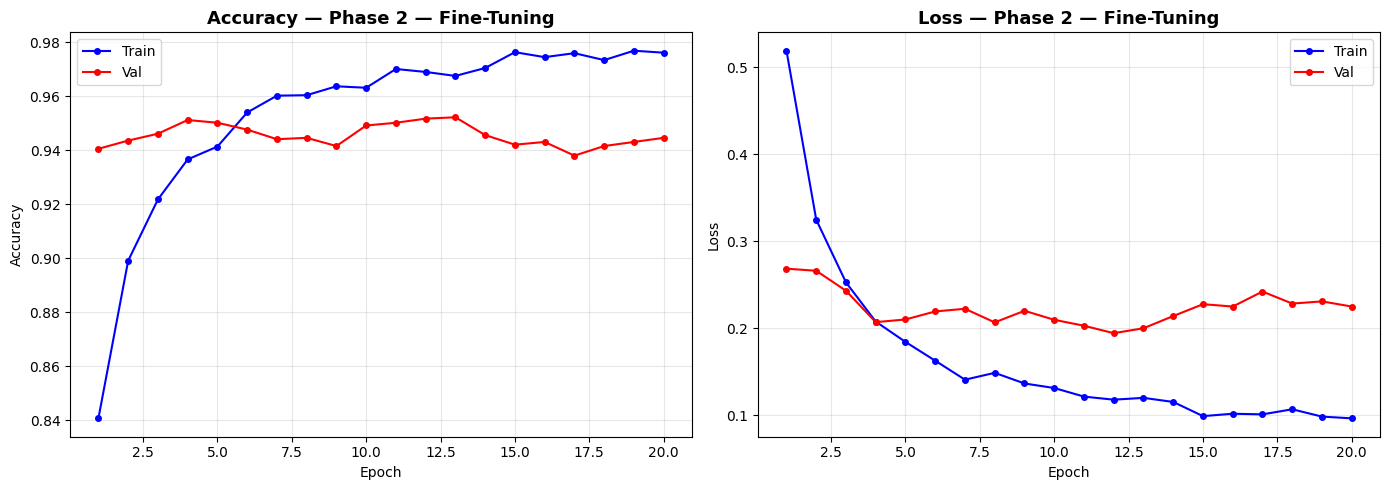

In [ ]:
plot_history(history2, 'Phase 2 — Fine-Tuning',
             save_path=OUTPUT_DIR/'training_phase2.png')


##  Cell 16 — Test Set Evaluation

In [ ]:
print(' Evaluating on test set …')
test_gen.reset()
loss, acc = model.evaluate(test_gen, verbose=1)
print(f'\n   ┌─────────────────────────────┐')
print(f'   │  Test Loss     : {loss:.4f}     │')
print(f'   │  Test Accuracy : {acc:.4f}     │')
print(f'   └─────────────────────────────┘')

test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

print('\n Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASSES))


 Evaluating on test set …
62/62 ━━━━━━━━━━━━━━━━━━━━ 28s 452ms/step - accuracy: 0.9524 - loss: 0.2044

   ┌─────────────────────────────┐
   │  Test Loss     : 0.2044     │
   │  Test Accuracy : 0.9524     │
   └─────────────────────────────┘
62/62 ━━━━━━━━━━━━━━━━━━━━ 26s 322ms/step

 Classification Report:
              precision    recall  f1-score   support

        cyst       0.91      0.99      0.95       557
      normal       0.97      0.98      0.97       763
       stone       0.97      0.90      0.93       444
       tumor       0.98      0.86      0.92       211

    accuracy                           0.95      1975
   macro avg       0.96      0.93      0.94      1975
weighted avg       0.95      0.95      0.95      1975



##  Cell 17 — Confusion Matrix

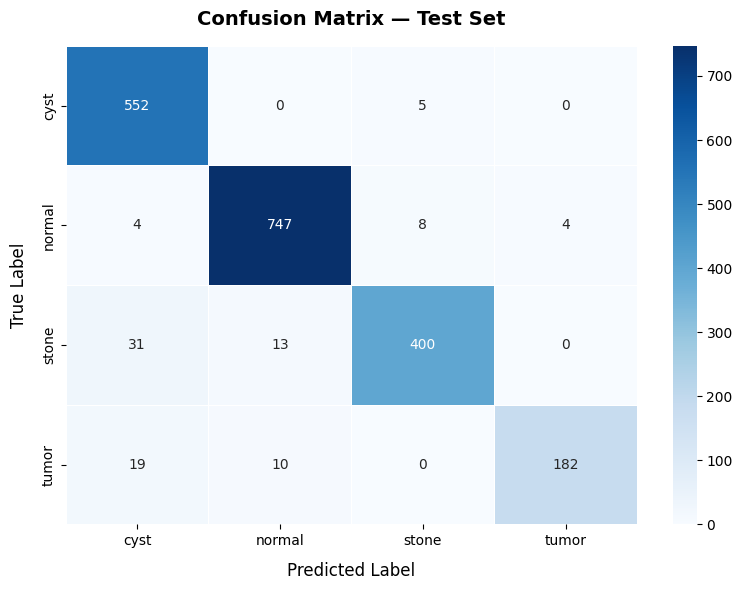

 Saved → /content/drive/MyDrive/Kidney____Project/outputs/confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('True Label',      fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved → {OUTPUT_DIR}/confusion_matrix.png')


## ROC Curve (One-vs-Rest) — Test Set

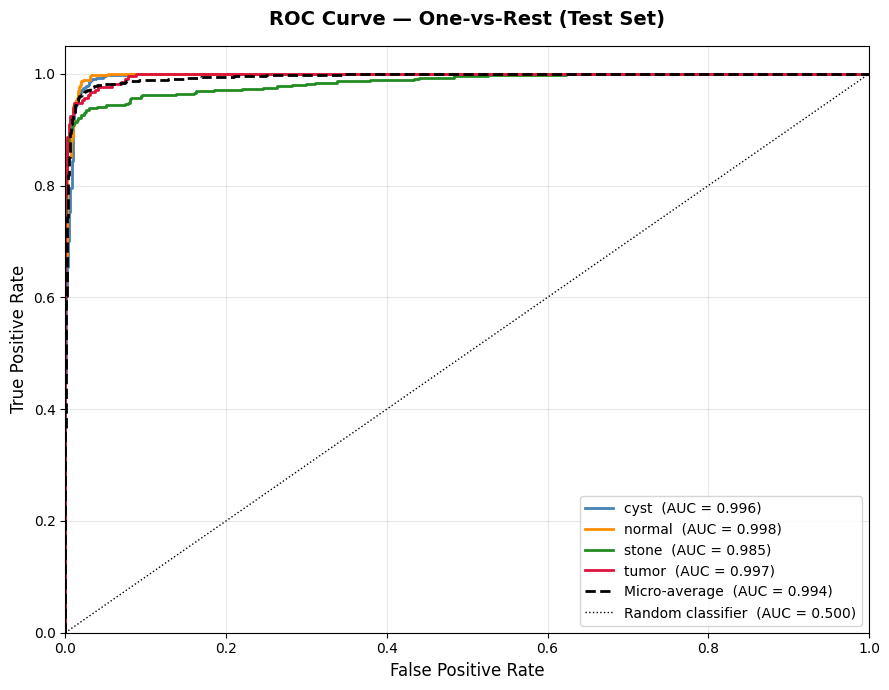

 Saved → /content/drive/MyDrive/Kidney____Project/outputs/roc_curve.png
   AUC [cyst    ] = 0.9962
   AUC [normal  ] = 0.9977
   AUC [stone   ] = 0.9850
   AUC [tumor   ] = 0.9968
   AUC [micro-avg] = 0.9944


In [ ]:
# ── ROC Curve: One-vs-Rest, per class + micro-average ─────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize ground-truth labels for one-vs-rest ROC computation
y_true_bin = label_binarize(y_true, classes=list(range(len(CLASSES))))
n_cls = y_true_bin.shape[1]

# Per-class ROC curve and AUC
fpr_dict, tpr_dict, auc_dict = {}, {}, {}
for i in range(n_cls):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

# Micro-average ROC (flatten all classes)
fpr_dict['micro'], tpr_dict['micro'], _ = roc_curve(
    y_true_bin.ravel(), y_pred_prob.ravel()
)
auc_dict['micro'] = auc(fpr_dict['micro'], tpr_dict['micro'])

# Plot ROC curves
colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
fig, ax = plt.subplots(figsize=(9, 7))

for i, (cls_name, color) in enumerate(zip(CLASSES, colors)):
    ax.plot(fpr_dict[i], tpr_dict[i], color=color, lw=2,
            label=f'{cls_name}  (AUC = {auc_dict[i]:.3f})')

# Micro-average curve
ax.plot(fpr_dict['micro'], tpr_dict['micro'],
        color='black', lw=2, linestyle='--',
        label=f'Micro-average  (AUC = {auc_dict["micro"]:.3f})')

# Random-guess baseline
ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Random classifier  (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — One-vs-Rest (Test Set)', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved → {OUTPUT_DIR}/roc_curve.png')
for i, cls_name in enumerate(CLASSES):
    print(f'   AUC [{cls_name:8s}] = {auc_dict[i]:.4f}')
print(f'   AUC [micro-avg] = {auc_dict["micro"]:.4f}')


## Grad-CAM++ Visualisation — Test Samples

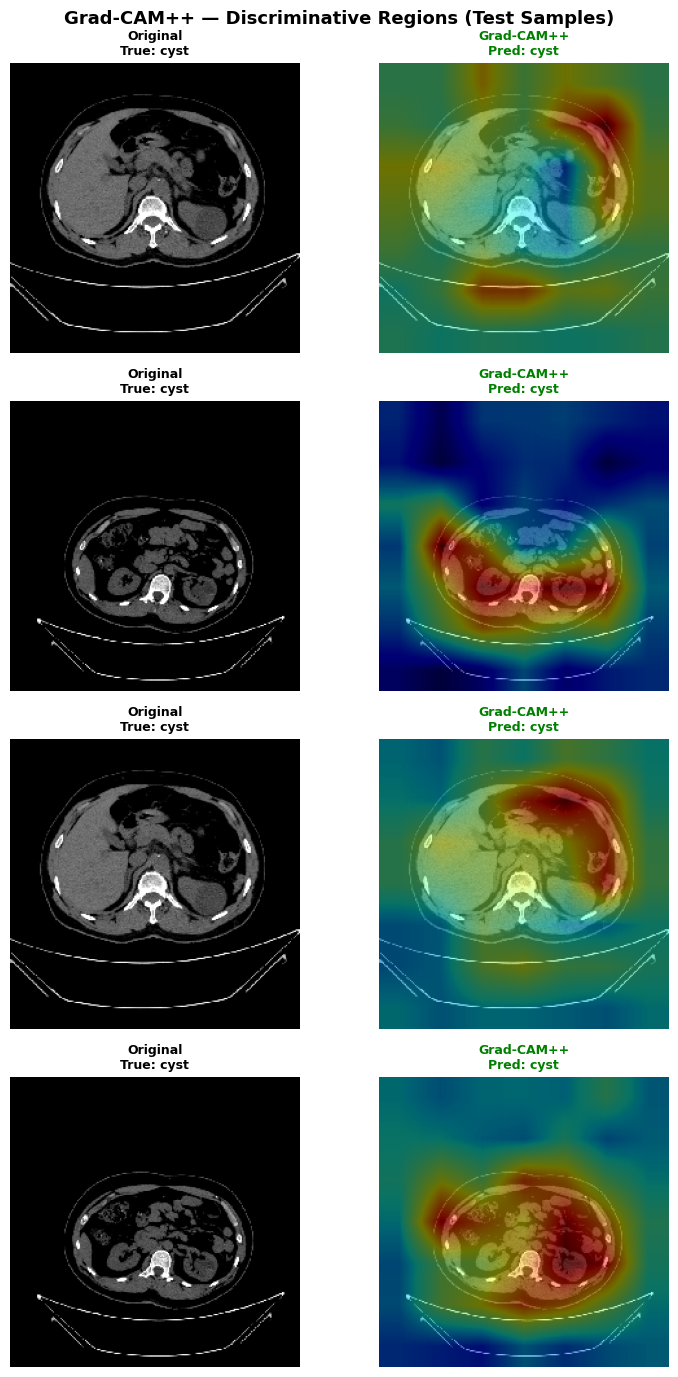

 Saved → /content/drive/MyDrive/Kidney____Project/outputs/gradcam_plus_plus.png


In [ ]:
# ── Grad-CAM++ Implementation ──────────────────────────────────────

def make_gradcam_pp_heatmap(model, img_array, last_conv_layer_name, class_idx=None):
    """
    Compute Grad-CAM++ heatmap for a single preprocessed image.

    Args:
        model               : Trained Keras model.
        img_array           : np.ndarray of shape (1, H, W, 3), values in [0, 1].
        last_conv_layer_name: Name of the last convolutional/feature layer.
        class_idx           : Target class index. If None, uses predicted class.

    Returns:
        cam      : np.ndarray (H_feat, W_feat) heatmap in [0, 1].
        class_idx: int, the class used for gradient computation.
    """
    # Sub-model: inputs → (last conv output, final predictions)
    grad_model = keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    img_t = tf.cast(img_array, tf.float32)

    # Forward pass inside a GradientTape to capture gradients
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_t, training=False)
        tape.watch(conv_out)        # watch intermediate feature maps
        if class_idx is None:
            class_idx = int(tf.argmax(preds[0]).numpy())
        score = preds[:, class_idx]

    # First-order gradients: dScore / dConvOutput
    grads = tape.gradient(score, conv_out)   # (1, H_f, W_f, C)

    grads_val = grads.numpy()[0]             # (H_f, W_f, C)
    conv_val  = conv_out.numpy()[0]          # (H_f, W_f, C)

    # Grad-CAM++ alpha weights (element-wise second/third-order approximation)
    grads2 = grads_val ** 2
    grads3 = grads_val ** 3

    # Denominator: 2*grad^2 + sum_spatial(A * grad^3)
    spatial_sum = conv_val.sum(axis=(0, 1), keepdims=True)   # (1, 1, C)
    alpha_denom = 2.0 * grads2 + spatial_sum * grads3
    # Avoid division by zero
    alpha_denom = np.where(np.abs(alpha_denom) < 1e-8,
                           np.ones_like(alpha_denom), alpha_denom)
    alphas = grads2 / alpha_denom

    # Per-channel weights: sum over spatial dims of (alpha * relu(grad))
    weights = np.sum(alphas * np.maximum(grads_val, 0), axis=(0, 1))  # (C,)

    # Weighted combination of feature maps → heatmap
    cam = np.sum(weights * conv_val, axis=-1)   # (H_f, W_f)
    cam = np.maximum(cam, 0)                     # ReLU

    # Normalise to [0, 1]
    if cam.max() > 0:
        cam /= cam.max()

    return cam, class_idx


def overlay_gradcam(img_array, cam, alpha_blend=0.45):
    """
    Resize cam to image spatial size and blend as a jet-colormap heatmap.

    Args:
        img_array  : np.ndarray (1, H, W, 3), values in [0, 1].
        cam        : np.ndarray (H_f, W_f), values in [0, 1].
        alpha_blend: Weight of the heatmap in the overlay.

    Returns:
        overlay: np.ndarray (H, W, 3), uint8.
    """
    img_uint8 = (img_array[0] * 255).astype(np.uint8)
    h, w = img_uint8.shape[:2]

    # Resize CAM to original image size using PIL (no cv2 dependency)
    cam_pil     = Image.fromarray((cam * 255).astype(np.uint8))
    cam_resized = np.array(cam_pil.resize((w, h), Image.BILINEAR)) / 255.0

    # Apply jet colormap
    heatmap_rgb = (plt.cm.jet(cam_resized)[:, :, :3] * 255).astype(np.uint8)

    # Alpha-blend heatmap onto original image
    overlay = (alpha_blend * heatmap_rgb + (1 - alpha_blend) * img_uint8).astype(np.uint8)
    return overlay


# ── Target: last spatial feature layer (Inception concat, before GAP) ──
GRADCAM_LAYER = 'incept_concat'

# ── Sample test images for visualisation ──────────────────────────
test_gen.reset()
sample_imgs_gc, sample_labels_gc = next(test_gen)  # one batch
n_gc = min(4, len(sample_imgs_gc))                  # visualise 4 samples
idx_to_cls_gc = {v: k for k, v in train_gen.class_indices.items()}

fig, axes = plt.subplots(n_gc, 2, figsize=(8, n_gc * 3.5))
if n_gc == 1:
    axes = axes[np.newaxis, :]   # keep 2-D indexing consistent

for i in range(n_gc):
    img_arr  = np.expand_dims(sample_imgs_gc[i], axis=0)   # (1, H, W, 3)
    true_cls = idx_to_cls_gc[int(sample_labels_gc[i])]

    # Compute Grad-CAM++ heatmap
    cam_map, pred_idx = make_gradcam_pp_heatmap(model, img_arr, GRADCAM_LAYER)
    pred_cls = idx_to_cls_gc[pred_idx]

    # Generate overlay
    overlay_img = overlay_gradcam(img_arr, cam_map, alpha_blend=0.45)
    color = 'green' if pred_cls == true_cls else 'red'

    # Original image column
    axes[i, 0].imshow(sample_imgs_gc[i])
    axes[i, 0].set_title(f'Original\nTrue: {true_cls}', fontsize=9, fontweight='bold')
    axes[i, 0].axis('off')

    # Grad-CAM++ overlay column
    axes[i, 1].imshow(overlay_img)
    axes[i, 1].set_title(f'Grad-CAM++\nPred: {pred_cls}',
                          fontsize=9, fontweight='bold', color=color)
    axes[i, 1].axis('off')

plt.suptitle('Grad-CAM++ — Discriminative Regions (Test Samples)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gradcam_plus_plus.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved → {OUTPUT_DIR}/gradcam_plus_plus.png')


##  Cell 18 — Sample Predictions Grid

Green = Correct prediction | Red = Wrong prediction

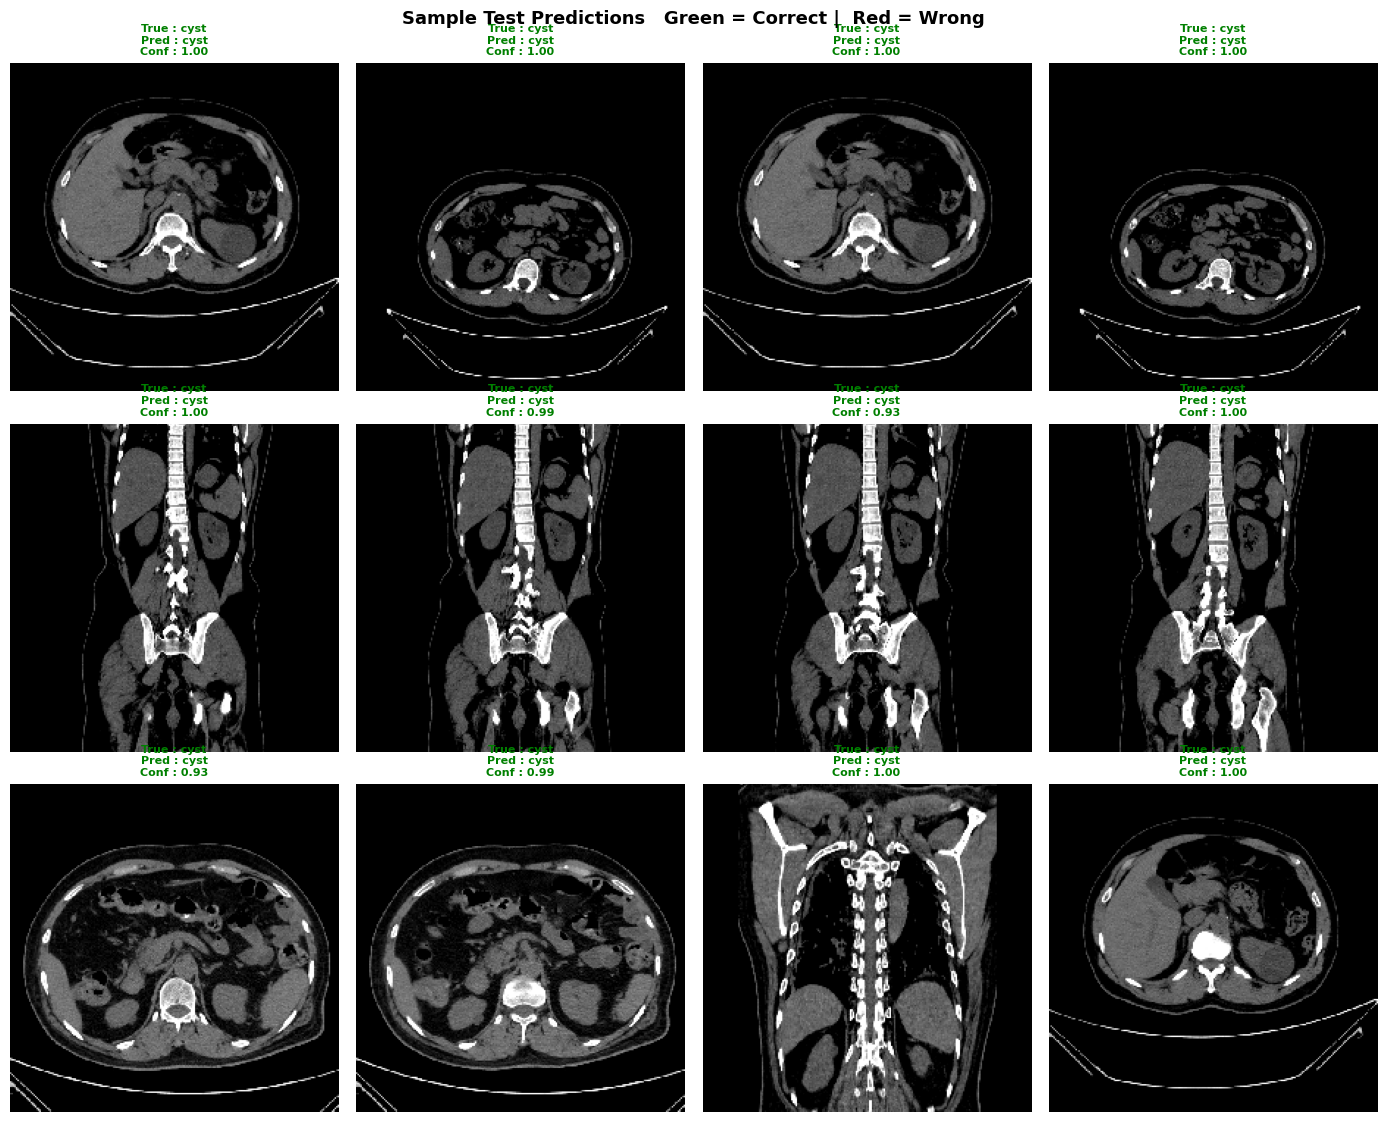

 Saved → /content/drive/MyDrive/Kidney____Project/outputs/sample_predictions.png


In [ ]:
test_gen.reset()
batch_imgs, batch_labels = next(test_gen)
batch_preds = np.argmax(model.predict(batch_imgs, verbose=0), axis=1)
idx_to_cls  = {v: k for k, v in train_gen.class_indices.items()}

n_show = min(12, len(batch_imgs))
cols   = 4
rows   = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*3.8))
axes = axes.flatten()

for i in range(n_show):
    true_cls = idx_to_cls[int(batch_labels[i])]
    pred_cls = idx_to_cls[int(batch_preds[i])]
    conf     = float(np.max(y_pred_prob[i])) if i < len(y_pred_prob) else 0.0
    color    = 'green' if true_cls == pred_cls else 'red'
    axes[i].imshow(batch_imgs[i])
    axes[i].set_title(f'True : {true_cls}\nPred : {pred_cls}\nConf : {conf:.2f}',
                      color=color, fontsize=8, fontweight='bold')
    axes[i].axis('off')

for i in range(n_show, len(axes)): axes[i].axis('off')
plt.suptitle('Sample Test Predictions   Green = Correct |  Red = Wrong',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved → {OUTPUT_DIR}/sample_predictions.png')


##  Cell 19 — Save Model

In [ ]:
keras_path = MODEL_DIR / 'kidney_disease_model.keras'
model.save(keras_path)
print(f' Keras model   → {keras_path}')

saved_path = MODEL_DIR / 'kidney_saved_model'
model.export(saved_path)
print(f' TF SavedModel → {saved_path}')

print('\n' + '='*55)
print('    Full pipeline complete!')
print('='*55)
print(f'  Models  → {MODEL_DIR}')
print(f'  Outputs → {OUTPUT_DIR}')
print('\n  Saved files:')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'     {f.name}')

 Keras model   → /content/drive/MyDrive/Kidney____Project/models/kidney_disease_model.keras
Saved artifact at '/content/drive/MyDrive/Kidney____Project/models/kidney_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_images')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138773737660560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138773737534672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138773737535248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138773737533136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138773737532944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138773737534480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138773737536016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138773737531024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138773737533